# `Malaria Cell Images Dataset` EDA pre GAN

Cieľ: pripraviť prehľad datasetu `cell_images` pre generovanie buniek pomocou GAN. Dataset obsahuje dve triedy:

- `Parasitized`
- `Uninfected`

Notebook robí základné EDA, vizualizuje distribúciu veľkostí a ukazuje náhodné ukážky obrázkov.

In [3]:
from pathlib import Path
from collections import Counter
import random

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Dataset a helper funkcie

Najprv si načítame cesty a nastavíme pár pomocných funkcií. Pri EDA ignorujeme neobrázkové súbory ako `Thumbs.db`.

In [4]:
ROOT = Path('cell_images')
CLASSES = ['Parasitized', 'Uninfected']
VALID_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.webp'}

def load_rgb(path: Path):
    if path.suffix.lower() not in VALID_EXTENSIONS:
        return None
    try:
        with Image.open(path) as img:
            return img.convert('RGB').copy()
    except Exception:
        return None

def class_paths(root: Path):
    return {
        cls: sorted(p for p in (root / cls).iterdir() if p.is_file())
        for cls in CLASSES
    }

paths = class_paths(ROOT)
for cls in CLASSES:
    print(cls, len(paths[cls]))

Parasitized 13780
Uninfected 13780


## 2. Základná štatistika

Spočítame počet validných obrázkov, neplatné súbory, rozsah rozlíšení a základné farebné štatistiky.

In [5]:
def class_stats(paths_for_class):
    sizes = Counter()
    mode_counts = Counter()
    invalid = []
    widths = []
    heights = []
    valid = []

    for p in paths_for_class:
        img = load_rgb(p)
        if img is None:
            invalid.append(p.name)
            continue
        valid.append(p)
        sizes[img.size] += 1
        mode_counts['RGB'] += 1
        widths.append(img.size[0])
        heights.append(img.size[1])

    sample = random.Random(42).sample(valid, min(200, len(valid)))
    total = np.zeros(3, dtype=np.float64)
    total_sq = np.zeros(3, dtype=np.float64)
    pixels = 0
    for p in sample:
        img = load_rgb(p)
        if img is None:
            continue
        arr = np.asarray(img, dtype=np.float32) / 255.0
        flat = arr.reshape(-1, 3)
        total += flat.sum(axis=0)
        total_sq += np.square(flat).sum(axis=0)
        pixels += flat.shape[0]

    mean = total / pixels
    var = np.maximum(total_sq / pixels - np.square(mean), 0.0)
    std = np.sqrt(var)

    return {
        'total_files': len(paths_for_class),
        'valid_images': len(valid),
        'invalid_files': invalid,
        'unique_sizes': len(sizes),
        'size_range': (min(widths), max(widths), min(heights), max(heights)),
        'top_sizes': sizes.most_common(10),
        'mean_rgb': mean,
        'std_rgb': std,
    }

stats = {cls: class_stats(paths[cls]) for cls in CLASSES}
total_valid = sum(stats[cls]['valid_images'] for cls in CLASSES)
total_invalid = sum(len(stats[cls]['invalid_files']) for cls in CLASSES)
balance = stats['Parasitized']['valid_images'] / stats['Uninfected']['valid_images']

print('Valid images:', total_valid)
print('Invalid files:', total_invalid)
print('Class balance ratio:', round(balance, 4))
for cls in CLASSES:
    s = stats[cls]
    print('\n', cls)
    print('  valid:', s['valid_images'])
    print('  invalid:', s['invalid_files'])
    print('  unique sizes:', s['unique_sizes'])
    print('  size range:', s['size_range'])
    print('  mean RGB:', np.round(s['mean_rgb'], 4))
    print('  std RGB:', np.round(s['std_rgb'], 4))

Valid images: 27558
Invalid files: 2
Class balance ratio: 1.0

 Parasitized
  valid: 13779
  invalid: ['Thumbs.db']
  unique sizes: 1402
  size range: (46, 394, 40, 385)
  mean RGB: [0.5216 0.3982 0.4283]
  std RGB: [0.3533 0.2754 0.2896]

 Uninfected
  valid: 13779
  invalid: ['Thumbs.db']
  unique sizes: 1207
  size range: (49, 247, 49, 235)
  mean RGB: [0.5258 0.4377 0.4604]
  std RGB: [0.3394 0.2818 0.2959]


## 3. Duplicity

Skontrolujeme presné duplicity podľa obsahu súborov. To je užitočné pred tréningom, aby si nezavadzal redundantné vzorky do datasetu.

In [6]:
import hashlib
from collections import defaultdict

def file_hash(path):
    h = hashlib.md5()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

hash_to_entries = defaultdict(list)
for cls in CLASSES:
    for p in paths[cls]:
        if load_rgb(p) is None:
            continue
        hash_to_entries[file_hash(p)].append((cls, p.name))

duplicate_groups = [entries for entries in hash_to_entries.values() if len(entries) > 1]
cross_class_groups = [
    entries for entries in duplicate_groups
    if len({cls for cls, _ in entries}) > 1
]

print('Duplicate groups:', len(duplicate_groups))
print('Cross-class duplicate groups:', len(cross_class_groups))
for entries in duplicate_groups[:10]:
    print(entries)


Duplicate groups: 0
Cross-class duplicate groups: 0


## 4. Počet obrázkov v triedach

Triedy sú prakticky vyvážené, čo je pre GAN výborné.

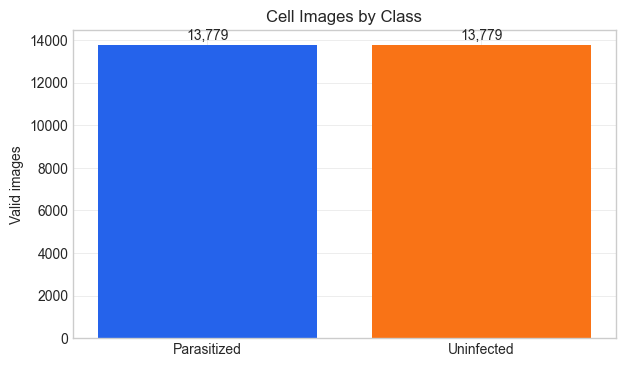

In [7]:
labels = CLASSES
counts = [stats[c]['valid_images'] for c in labels]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts, color=['#2563eb', '#f97316'])
ax.set_title('Cell Images by Class')
ax.set_ylabel('Valid images')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 100, f'{count:,}', ha='center', va='bottom')
plt.show()

## 5. Distribúcia rozlíšení

Dataset obsahuje veľa rôznych rozmerov, preto bude treba fixný resize pred tréningom GAN.

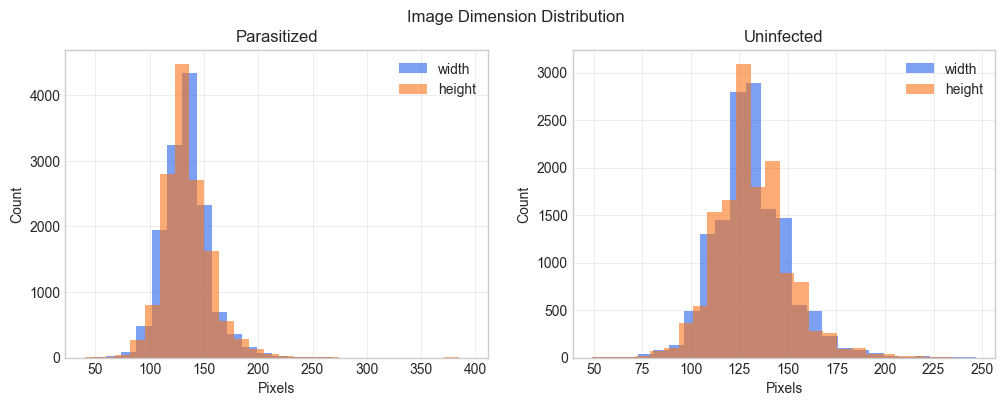

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cls in zip(axes, CLASSES):
    widths = []
    heights = []
    for p in paths[cls]:
        if p.suffix.lower() not in VALID_EXTENSIONS:
            continue
        try:
            with Image.open(p) as img:
                widths.append(img.size[0])
                heights.append(img.size[1])
        except Exception:
            pass
    ax.hist(widths, bins=25, alpha=0.6, label='width', color='#2563eb')
    ax.hist(heights, bins=25, alpha=0.6, label='height', color='#f97316')
    ax.set_title(cls)
    ax.set_xlabel('Pixels')
    ax.set_ylabel('Count')
    ax.legend()
plt.suptitle('Image Dimension Distribution')
plt.show()

## 6. Najčastejšie rozmery

Väčšina obrázkov sa sústreďuje okolo podobných veľkostí, ale nie je to striktne jednotné.

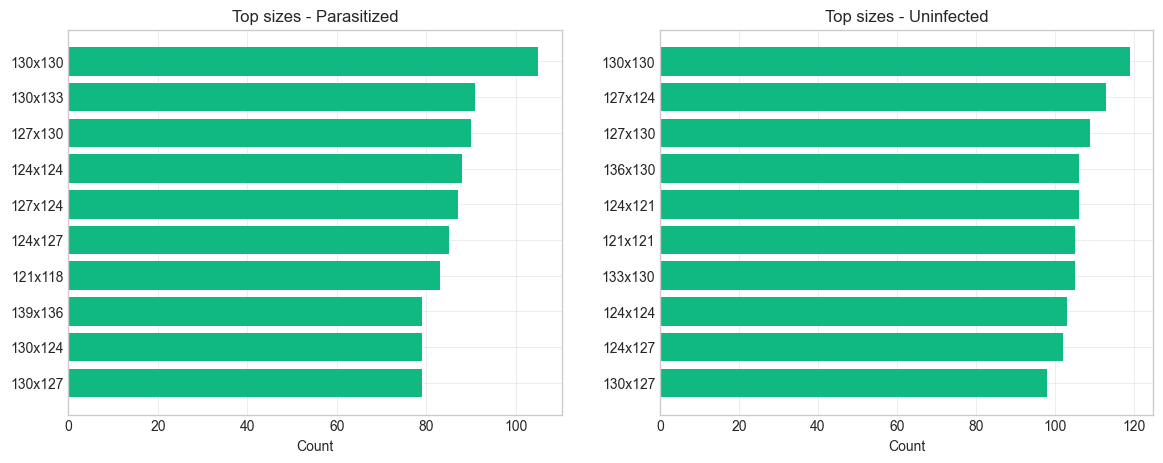

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cls in zip(axes, CLASSES):
    top = stats[cls]['top_sizes'][:10]
    labels = [f'{w}x{h}' for (w, h), _ in top]
    values = [count for _, count in top]
    ax.barh(labels[::-1], values[::-1], color='#10b981')
    ax.set_title(f'Top sizes - {cls}')
    ax.set_xlabel('Count')
plt.show()

## 7. Náhodné ukážky

Na prvý pohľad vyzerajú bunky už dobre orezané. Pozadie je prevažne tmavé a bunky sú v strede, čo je dobré pre generatívny model.

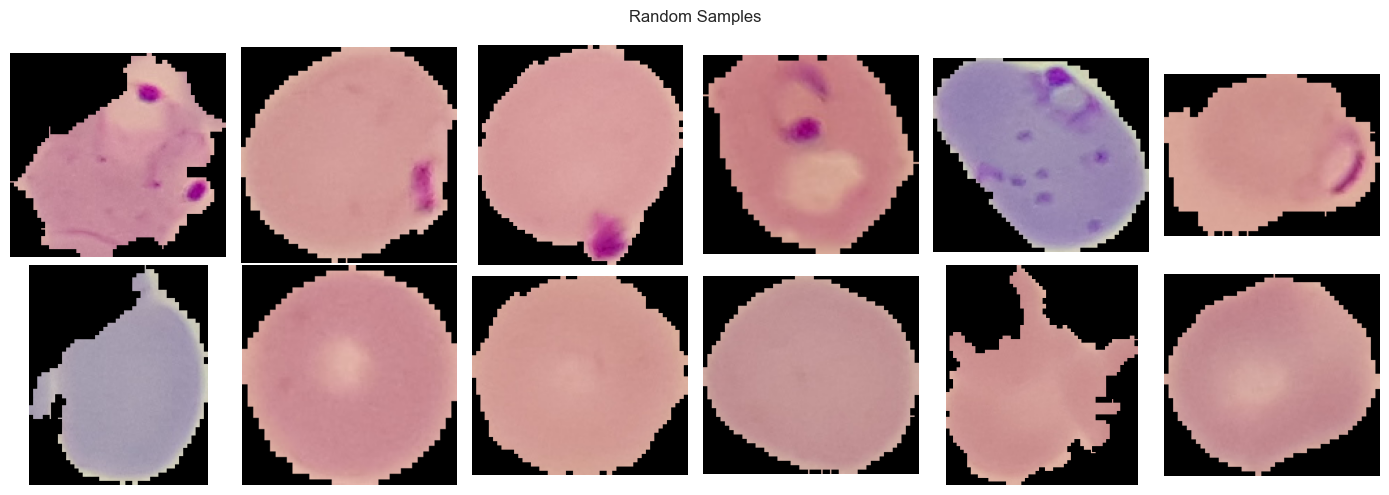

In [10]:
rng = random.Random(42)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for row, cls in enumerate(CLASSES):
    candidates = [p for p in paths[cls] if load_rgb(p) is not None]
    picks = candidates if len(candidates) <= 6 else rng.sample(candidates, 6)
    for col in range(6):
        ax = axes[row, col]
        ax.axis('off')
        if col < len(picks):
            ax.imshow(load_rgb(picks[col]))
    axes[row, 0].set_ylabel(cls, rotation=0, labelpad=40, va='center', fontsize=11)
plt.suptitle('Random Samples')
plt.tight_layout()
plt.show()

## 8. Formáty a režimy

Najprv overíme, v akom formáte sú súbory na disku a v akom image mode sa načítajú. Až potom dáva zmysel robiť RGB analýzu.

In [11]:
def format_and_mode_stats(paths_by_class):
    file_exts = Counter()
    pil_formats = Counter()
    modes = Counter()
    invalid = []

    for cls in CLASSES:
        for p in paths_by_class[cls]:
            file_exts[p.suffix.lower()] += 1
            img = load_rgb(p)
            if img is None:
                invalid.append(p.name)
                continue
            try:
                with Image.open(p) as raw:
                    pil_formats[raw.format or 'UNKNOWN'] += 1
                    modes[raw.mode] += 1
            except Exception:
                invalid.append(p.name)

    return file_exts, pil_formats, modes, invalid

file_exts, pil_formats, modes, invalid = format_and_mode_stats(paths)
print('File extensions:', dict(file_exts))
print('PIL formats:', dict(pil_formats))
print('Image modes:', dict(modes))
print('Invalid files:', invalid)
assert modes == Counter({'RGB': sum(stats[c]['valid_images'] for c in CLASSES)})
assert pil_formats == Counter({'PNG': sum(stats[c]['valid_images'] for c in CLASSES)})

File extensions: {'.png': 27558, '.db': 2}
PIL formats: {'PNG': 27558}
Image modes: {'RGB': 27558}
Invalid files: ['Thumbs.db', 'Thumbs.db']


## 9. Intenzity kanálov

Keďže sme overili, že validné obrázky sú RGB PNG súbory, pozrieme sa len na priemerné intenzity farebných kanálov pre obe triedy.

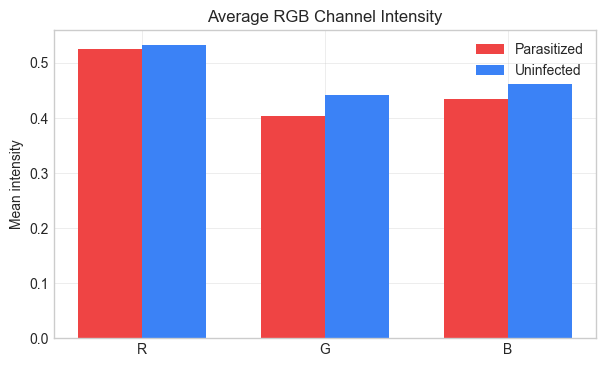

Parasitized [0.525  0.4037 0.4344]
Uninfected [0.5324 0.4407 0.4622]


In [12]:
def channel_means(image_paths):
    total = np.zeros(3, dtype=np.float64)
    total_pixels = 0
    for p in image_paths:
        img = load_rgb(p)
        if img is None:
            continue
        arr = np.asarray(img, dtype=np.float32) / 255.0
        flat = arr.reshape(-1, 3)
        total += flat.sum(axis=0)
        total_pixels += flat.shape[0]
    return total / total_pixels

channel_summary = {
    cls: channel_means(paths[cls])
    for cls in CLASSES
}

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
width = 0.35
ax.bar(x - width / 2, channel_summary['Parasitized'], width, label='Parasitized', color='#ef4444')
ax.bar(x + width / 2, channel_summary['Uninfected'], width, label='Uninfected', color='#3b82f6')
ax.set_xticks(x)
ax.set_xticklabels(['R', 'G', 'B'])
ax.set_ylabel('Mean intensity')
ax.set_title('Average RGB Channel Intensity')
ax.legend()
plt.show()

for cls, values in channel_summary.items():
    print(cls, np.round(values, 4))

## 10. Aspect ratio a jas

Okrem samotných rozmerov je užitočné pozrieť sa na pomer strán a priemerný jas obrázkov.

Parasitized
  aspect ratio mean: 1.006
  aspect ratio std: 0.1505
  brightness mean: 0.457
  brightness std: 0.0461
Uninfected
  aspect ratio mean: 1.0085
  aspect ratio std: 0.1438
  brightness mean: 0.4806
  brightness std: 0.0445


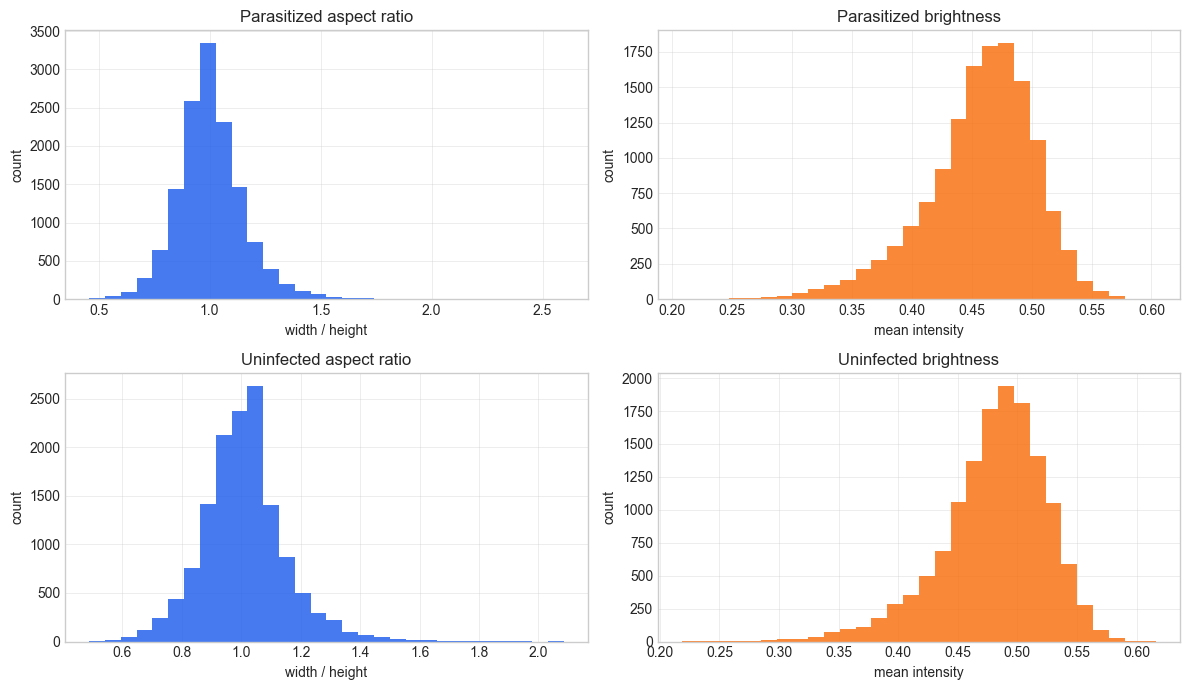

In [13]:
def image_shape_metrics(paths_for_class):
    aspect_ratios = []
    brightness = []
    for p in paths_for_class:
        img = load_rgb(p)
        if img is None:
            continue
        arr = np.asarray(img, dtype=np.float32) / 255.0
        w, h = img.size
        aspect_ratios.append(w / h)
        brightness.append(float(arr.mean()))
    return np.array(aspect_ratios), np.array(brightness)

metrics = {cls: image_shape_metrics(paths[cls]) for cls in CLASSES}
for cls, (ratios, bright) in metrics.items():
    print(cls)
    print('  aspect ratio mean:', round(float(ratios.mean()), 4))
    print('  aspect ratio std:', round(float(ratios.std()), 4))
    print('  brightness mean:', round(float(bright.mean()), 4))
    print('  brightness std:', round(float(bright.std()), 4))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, cls in enumerate(CLASSES):
    ratios, bright = metrics[cls]
    axes[row, 0].hist(ratios, bins=30, color='#2563eb', alpha=0.85)
    axes[row, 0].set_title(f'{cls} aspect ratio')
    axes[row, 0].set_xlabel('width / height')
    axes[row, 0].set_ylabel('count')
    axes[row, 1].hist(bright, bins=30, color='#f97316', alpha=0.85)
    axes[row, 1].set_title(f'{cls} brightness')
    axes[row, 1].set_xlabel('mean intensity')
    axes[row, 1].set_ylabel('count')
plt.tight_layout()
plt.show()


## 11. Preprocessing pipeline

Toto je spoločná prípravná vrstva pre všetky ďalšie experimenty.

Robíme tu:
- validáciu ciest a vyradenie neplatných súborov
- načítanie iba RGB obrázkov
- resize na fixný rozmer `128x128`
- konverziu do `float32`
- normalizáciu pixelov do rozsahu `[-1, 1]`
- batch loader pre tréning GAN-u
- balanced split na `train / val / test`
- zachovanie vyváženosti tried `Parasitized` a `Uninfected`

Split je približne:
- `train`: `80%`
- `val`: `10%`
- `test`: `10%`


In [14]:
try:
    RESAMPLE = Image.Resampling.BILINEAR
except AttributeError:
    RESAMPLE = Image.BILINEAR

TARGET_SIZE = (128, 128)
CHANNELS = 3
NORMALIZE_RANGE = (-1.0, 1.0)
RNG = np.random.default_rng(42)

def list_valid_images(class_paths):
    valid = []
    invalid = []
    for p in class_paths:
        img = load_rgb(p)
        if img is None:
            invalid.append(p)
        else:
            valid.append(p)
    return valid, invalid

def load_preprocessed_image(path, target_size=TARGET_SIZE, normalize=True):
    img = load_rgb(path)
    if img is None:
        return None
    arr = np.asarray(img.resize(target_size, RESAMPLE), dtype=np.float32) / 255.0
    if normalize:
        arr = arr * 2.0 - 1.0
    return arr

def batch_images(image_paths, batch_size=32, target_size=TARGET_SIZE, shuffle=True, normalize=True):
    paths_local = list(image_paths)
    if shuffle:
        RNG.shuffle(paths_local)
    for start in range(0, len(paths_local), batch_size):
        batch_paths = paths_local[start:start + batch_size]
        batch = []
        for p in batch_paths:
            arr = load_preprocessed_image(p, target_size=target_size, normalize=normalize)
            if arr is not None:
                batch.append(arr)
        if batch:
            yield np.stack(batch, axis=0)

def balanced_split(paths_by_class, val_ratio=0.1, test_ratio=0.1, seed=42):
    rng = np.random.default_rng(seed)
    splits = {"train": {}, "val": {}, "test": {}}
    for cls, cls_paths in paths_by_class.items():
        items = np.array(cls_paths, dtype=object)
        rng.shuffle(items)
        n = len(items)
        n_test = int(n * test_ratio)
        n_val = int(n * val_ratio)
        splits["test"][cls] = items[:n_test].tolist()
        splits["val"][cls] = items[n_test:n_test + n_val].tolist()
        splits["train"][cls] = items[n_test + n_val:].tolist()
    return splits

valid_paths = {}
invalid_paths = {}
for cls in CLASSES:
    valid_paths[cls], invalid_paths[cls] = list_valid_images(paths[cls])

splits = balanced_split(valid_paths, val_ratio=0.1, test_ratio=0.1, seed=42)

print('Pipeline settings:')
print('  TARGET_SIZE:', TARGET_SIZE)
print('  CHANNELS:', CHANNELS)
print('  NORMALIZE_RANGE:', NORMALIZE_RANGE)
print('  batch_images(...) -> numpy batches ready for GAN training')

print('Split sizes:')
for split_name in ['train', 'val', 'test']:
    print(f'  {split_name}:')
    for cls in CLASSES:
        print(f'    {cls}: {len(splits[split_name][cls])}')

print('Invalid files kept out of training:')
for cls in CLASSES:
    print(f'  {cls}: {len(invalid_paths[cls])}')


Pipeline settings:
  TARGET_SIZE: (128, 128)
  CHANNELS: 3
  NORMALIZE_RANGE: (-1.0, 1.0)
  batch_images(...) -> numpy batches ready for GAN training
Split sizes:
  train:
    Parasitized: 11025
    Uninfected: 11025
  val:
    Parasitized: 1377
    Uninfected: 1377
  test:
    Parasitized: 1377
    Uninfected: 1377
Invalid files kept out of training:
  Parasitized: 1
  Uninfected: 1


## 12. Treningove prostredie a logovanie

V dalsich bunkach pridame rovnaku experimentacnu kostru ako v `Animal10.ipynb`, ale pre generativne modely. Cielom je mat vsetky hlavne parametre na jednom mieste, jednotny sposob logovania do `wandb` a konzistentne ukladanie checkpointov.

Kazdy checkpoint ulozi:
- stav generatora aj diskriminatora,
- kompletnu konfiguraciu experimentu,
- fixny `noise` tensor pre porovnanie,
- sample grid vygenerovany z toho isteho latentneho vstupu.


In [15]:
import copy
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.optim as optim
import wandb

from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from dotenv import load_dotenv


load_dotenv()

WANDB_API_KEY = os.getenv('WANDB_API_KEY')
if WANDB_API_KEY:
    os.environ['WANDB_API_KEY'] = WANDB_API_KEY

wandb.login(key=WANDB_API_KEY, relogin=False) if WANDB_API_KEY else wandb.login(anonymous='allow', relogin=False)


if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print('Device:', DEVICE)

CHECKPOINT_ROOT = Path('checkpoints/gan')
for directory in [CHECKPOINT_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)


C:\Users\lujvi\PycharmProjects\Nsiete_projekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
wandb: WARNING The anonymous parameter to wandb.login() has no effect and will be removed in future versions.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\lujvi\_netrc.
wandb: Currently logged in as: lui-vitarius (lui-vitarius-slovak-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Device: cpu


## 13. Definicia konfiguracie a experimentov

Podobne ako pri klasifikacii budeme mat jeden spolocny zaklad a jednotlive experimenty budu menit len to, co je skutocne potrebne. Prve behy ostavaju plne `from scratch` v PyTorchi a az neskor sa da na tento ramec jednoducho doplnit perceptual loss alebo pretrained backbone.


In [16]:
GAN_BASE_CONFIG = {
    'project': 'NSIETE_GAN_Malaria',
    'entity': os.getenv('WANDB_ENTITY') or None,
    'seed': 42,
    'data': {
        'selected_classes': CLASSES,
        'target_size': 128,
        'batch_size': 64,
        'num_workers': 0,
        'shuffle': True,
        'drop_last': True,
        'horizontal_flip': True,
    },
    'model': {
        'image_channels': 3,
        'latent_dim': 128,
        'base_channels': 64,
        'generator_batchnorm': True,
        'discriminator_batchnorm': True,
        'discriminator_dropout': 0.0,
        'leaky_relu_slope': 0.2,
    },
    'optimization': {
        'gan_type': 'vanilla',
        'g_lr': 2e-4,
        'd_lr': 2e-4,
        'betas': (0.5, 0.999),
        'weight_decay': 0.0,
        'n_critic': 1,
        'real_label': 0.9,
        'fake_label': 0.0,
        'label_noise': 0.0,
        'gradient_penalty_lambda': 10.0,
    },
    'trainer': {
        'epochs': 30,
        'max_train_batches': None,
        'log_every_steps': 50,
        'checkpoint_every': 5,
        'num_fixed_samples': 16,
    },
}


In [17]:

def deep_update(base, updates):
    merged = copy.deepcopy(base)
    for key, value in updates.items():
        if isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key] = deep_update(merged[key], value)
        else:
            merged[key] = value
    return merged



def make_experiment(run_name, description, **updates):
    cfg = deep_update(GAN_BASE_CONFIG, updates)
    cfg['run_name'] = run_name
    cfg['description'] = description
    return cfg


In [18]:

EXPERIMENTS = [
    make_experiment(
        run_name='basic_gan_scratch',
        description='Zakladny GAN od nuly so sigmoid diskriminatorom a BCE loss.',
        model={
            'base_channels': 32,
            'generator_batchnorm': False,
            'discriminator_batchnorm': False,
        },
        trainer={
            'epochs': 60,
            'checkpoint_every': 5,
        },
    ),
    make_experiment(
        run_name='dcgan_scratch',
        description='Silnejsi DCGAN z nulovej inicializacie s batch norm a jemnym label smoothingom.',
        model={
            'base_channels': 64,
            'generator_batchnorm': True,
            'discriminator_batchnorm': True,
        },
        optimization={
            'gan_type': 'vanilla',
            'real_label': 0.9,
            'fake_label': 0.0,
            'label_noise': 0.05,
        },
        trainer={
            'epochs': 80,
            'checkpoint_every': 5,
        },
    ),
    make_experiment(
        run_name='lsgan_scratch',
        description='Least-Squares GAN ako stabilnejsia alternativa ku klasickemu BCE GAN-u.',
        model={
            'base_channels': 64,
            'generator_batchnorm': True,
            'discriminator_batchnorm': True,
        },
        optimization={
            'gan_type': 'lsgan',
        },
        trainer={
            'epochs': 80,
            'checkpoint_every': 5,
        },
    ),
    make_experiment(
        run_name='wgan_gp_scratch',
        description='WGAN-GP s critic update 5x na batch a gradient penalty pre lepsiu stabilitu.',
        model={
            'base_channels': 64,
            'generator_batchnorm': True,
            'discriminator_batchnorm': False,
            'discriminator_dropout': 0.0,
        },
        optimization={
            'gan_type': 'wgan-gp',
            'n_critic': 5,
            'gradient_penalty_lambda': 10.0,
            'd_lr': 1e-4,
            'g_lr': 1e-4,
            'betas': (0.0, 0.9),
        },
        trainer={
            'epochs': 120,
            'checkpoint_every': 5,
        },
    ),
]

experiment_overview = pd.DataFrame([
    {
        'run_name': cfg['run_name'],
        'gan_type': cfg['optimization']['gan_type'],
        'epochs': cfg['trainer']['epochs'],
        'batch_size': cfg['data']['batch_size'],
        'latent_dim': cfg['model']['latent_dim'],
        'base_channels': cfg['model']['base_channels'],
        'n_critic': cfg['optimization']['n_critic'],
        'description': cfg['description'],
    }
    for cfg in EXPERIMENTS
])

experiment_overview


,run_name,gan_type,epochs,batch_size,latent_dim,base_channels,n_critic,description
0,basic_gan_scratch,vanilla,20,64,128,32,1,Zakladny GAN od nuly so sigmoid diskriminatoro...
1,dcgan_scratch,vanilla,30,64,128,64,1,Silnejsi DCGAN z nulovej inicializacie s batch...
2,lsgan_scratch,lsgan,30,64,128,64,1,Least-Squares GAN ako stabilnejsia alternativa...
3,wgan_gp_scratch,wgan-gp,40,64,128,64,5,WGAN-GP s critic update 5x na batch a gradient...


### Prehlad experimentov

- `basic_gan_scratch`: najjednoduchsia referencia, aby sme mali jasny baseline bez stabilizacnych trikov.
- `dcgan_scratch`: rovnaky problem, ale s DCGAN stylom architektury a miernym smoothingom labelov.
- `lsgan_scratch`: meni sa hlavne cielova funkcia, co casto pomaha so stabilitou treningu.
- `wgan_gp_scratch`: nejsilnejsi scratch variant, kde sa BCE nahradi Wasserstein cielom a gradient penalty.

Vsetky experimenty zdielaju rovnaky sposob nacitania dat, fixny latentny vstup pre checkpoint samples aj jednotny zapis do `wandb`.


In [19]:
class MalariaGanDataset(Dataset):
    def __init__(self, image_paths, target_size, horizontal_flip=True):
        self.image_paths = [Path(p) for p in image_paths]
        self.target_size = (target_size, target_size)
        self.horizontal_flip = horizontal_flip

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        path = self.image_paths[index]
        image = load_rgb(path)
        if image is None:
            raise RuntimeError(f'Invalid image during training: {path}')

        image = image.resize(self.target_size, RESAMPLE)
        if self.horizontal_flip and random.random() < 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)

        arr = np.asarray(image, dtype=np.float32) / 255.0
        arr = arr * 2.0 - 1.0
        tensor = torch.from_numpy(arr).permute(2, 0, 1).contiguous()
        return tensor



def flatten_split_paths(split_name, selected_classes=None):
    selected_classes = selected_classes or CLASSES
    merged = []
    for cls in selected_classes:
        merged.extend(splits[split_name][cls])
    return merged



def build_gan_dataloader(config):
    data_cfg = config['data']
    image_paths = flatten_split_paths('train', data_cfg.get('selected_classes'))
    dataset = MalariaGanDataset(
        image_paths=image_paths,
        target_size=data_cfg['target_size'],
        horizontal_flip=data_cfg.get('horizontal_flip', True),
    )
    loader = DataLoader(
        dataset,
        batch_size=data_cfg['batch_size'],
        shuffle=data_cfg.get('shuffle', True),
        num_workers=data_cfg.get('num_workers', 0),
        drop_last=data_cfg.get('drop_last', True),
        pin_memory=torch.cuda.is_available(),
    )
    return dataset, loader



def denormalize_tensor(images):
    return images.detach().cpu().clamp(-1.0, 1.0).add(1.0).div(2.0)



def make_image_grid(images, nrow=4):
    images = denormalize_tensor(images)
    batch, channels, height, width = images.shape
    nrow = max(1, min(nrow, batch))
    ncol = math.ceil(batch / nrow)
    grid = torch.zeros(channels, ncol * height, nrow * width)
    for idx, image in enumerate(images):
        row = idx // nrow
        col = idx % nrow
        grid[:, row * height:(row + 1) * height, col * width:(col + 1) * width] = image
    return grid



def save_image_grid(images, path, nrow=4):
    grid = make_image_grid(images, nrow=nrow)
    array = (grid.permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
    Image.fromarray(array).save(path)
    return path


preview_dataset, preview_loader = build_gan_dataloader(EXPERIMENTS[0])
preview_batch = next(iter(preview_loader))
print('Train images prepared for GAN:', len(preview_dataset))
print('One batch shape:', tuple(preview_batch.shape))
print('Pixel range:', float(preview_batch.min()), float(preview_batch.max()))


Train images prepared for GAN: 22050
One batch shape: (64, 3, 128, 128)
Pixel range: -1.0 0.8588235378265381


In [20]:
def make_generator_block(in_channels, out_channels, kernel_size=4, stride=2, padding=1, use_batchnorm=True):
    layers = [nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)]
    if use_batchnorm:
        layers.append(nn.BatchNorm2d(out_channels))
    layers.append(nn.ReLU(True))
    return layers



def make_discriminator_block(in_channels, out_channels, kernel_size=4, stride=2, padding=1, use_batchnorm=True, dropout=0.0, negative_slope=0.2):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)]
    if use_batchnorm:
        layers.append(nn.BatchNorm2d(out_channels))
    layers.append(nn.LeakyReLU(negative_slope, inplace=True))
    if dropout > 0:
        layers.append(nn.Dropout2d(dropout))
    return layers

In [21]:


class Generator128(nn.Module):
    def __init__(self, latent_dim=128, image_channels=3, base_channels=64, use_batchnorm=True):
        super().__init__()
        self.net = nn.Sequential(
            *make_generator_block(latent_dim, base_channels * 16, stride=1, padding=0, use_batchnorm=use_batchnorm),
            *make_generator_block(base_channels * 16, base_channels * 8, use_batchnorm=use_batchnorm),
            *make_generator_block(base_channels * 8, base_channels * 4, use_batchnorm=use_batchnorm),
            *make_generator_block(base_channels * 4, base_channels * 2, use_batchnorm=use_batchnorm),
            *make_generator_block(base_channels * 2, base_channels, use_batchnorm=use_batchnorm),
            nn.ConvTranspose2d(base_channels, image_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, noise):
        return self.net(noise)


class Discriminator128(nn.Module):
    def __init__(self, image_channels=3, base_channels=64, use_batchnorm=True, dropout=0.0, negative_slope=0.2, use_sigmoid=True):
        super().__init__()
        layers = []
        layers.extend(make_discriminator_block(image_channels, base_channels, use_batchnorm=False, dropout=dropout, negative_slope=negative_slope))
        layers.extend(make_discriminator_block(base_channels, base_channels * 2, use_batchnorm=use_batchnorm, dropout=dropout, negative_slope=negative_slope))
        layers.extend(make_discriminator_block(base_channels * 2, base_channels * 4, use_batchnorm=use_batchnorm, dropout=dropout, negative_slope=negative_slope))
        layers.extend(make_discriminator_block(base_channels * 4, base_channels * 8, use_batchnorm=use_batchnorm, dropout=dropout, negative_slope=negative_slope))
        layers.extend(make_discriminator_block(base_channels * 8, base_channels * 16, use_batchnorm=use_batchnorm, dropout=dropout, negative_slope=negative_slope))
        layers.append(nn.Conv2d(base_channels * 16, 1, kernel_size=4, stride=1, padding=0, bias=False))
        if use_sigmoid:
            layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, images):
        return self.net(images).view(-1)


In [22]:


def init_weights(module):
    classname = module.__class__.__name__
    if 'Conv' in classname or 'BatchNorm' in classname:
        if hasattr(module, 'weight') and module.weight is not None:
            nn.init.normal_(module.weight.data, 0.0, 0.02)
        if hasattr(module, 'bias') and module.bias is not None:
            nn.init.constant_(module.bias.data, 0.0)



def build_gan_models(config):
    model_cfg = config['model']
    gan_type = config['optimization']['gan_type']
    use_sigmoid = gan_type == 'vanilla'

    generator = Generator128(
        latent_dim=model_cfg['latent_dim'],
        image_channels=model_cfg['image_channels'],
        base_channels=model_cfg['base_channels'],
        use_batchnorm=model_cfg.get('generator_batchnorm', True),
    )
    discriminator = Discriminator128(
        image_channels=model_cfg['image_channels'],
        base_channels=model_cfg['base_channels'],
        use_batchnorm=model_cfg.get('discriminator_batchnorm', True),
        dropout=model_cfg.get('discriminator_dropout', 0.0),
        negative_slope=model_cfg.get('leaky_relu_slope', 0.2),
        use_sigmoid=use_sigmoid,
    )

    generator.apply(init_weights)
    discriminator.apply(init_weights)
    return generator.to(DEVICE), discriminator.to(DEVICE)


In [23]:
def make_noise(batch_size, latent_dim, device=DEVICE):
    return torch.randn(batch_size, latent_dim, 1, 1, device=device)



def smooth_labels(size, base_value, noise=0.0, device=DEVICE):
    labels = torch.full((size,), float(base_value), device=device)
    if noise > 0:
        labels = labels + (torch.rand_like(labels) * 2.0 - 1.0) * noise
    return labels.clamp(0.0, 1.0)



def compute_gradient_penalty(critic, real_images, fake_images):
    batch_size = real_images.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=real_images.device)
    interpolated = (alpha * real_images + (1.0 - alpha) * fake_images).requires_grad_(True)
    critic_scores = critic(interpolated)
    gradients = autograd.grad(
        outputs=critic_scores,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(batch_size, -1)
    return ((gradients.norm(2, dim=1) - 1.0) ** 2).mean()



def build_optimizers(generator, discriminator, config):
    opt_cfg = config['optimization']
    g_optimizer = optim.Adam(
        generator.parameters(),
        lr=opt_cfg['g_lr'],
        betas=tuple(opt_cfg['betas']),
        weight_decay=opt_cfg.get('weight_decay', 0.0),
    )
    d_optimizer = optim.Adam(
        discriminator.parameters(),
        lr=opt_cfg['d_lr'],
        betas=tuple(opt_cfg['betas']),
        weight_decay=opt_cfg.get('weight_decay', 0.0),
    )
    return g_optimizer, d_optimizer



def save_gan_checkpoint(run_name, epoch, generator, discriminator, g_optimizer, d_optimizer, fixed_noise, config, epoch_metrics):
    checkpoint_dir = CHECKPOINT_ROOT / run_name
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    generator.eval()
    with torch.no_grad():
        samples = generator(fixed_noise).detach().cpu()
    generator.train()

    checkpoint_path = checkpoint_dir / f'epoch_{epoch:03d}.pt'
    torch.save(
        {
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'g_optimizer_state_dict': g_optimizer.state_dict(),
            'd_optimizer_state_dict': d_optimizer.state_dict(),
            'fixed_noise': fixed_noise.detach().cpu(),
            'config': copy.deepcopy(config),
            'epoch_metrics': dict(epoch_metrics),
        },
        checkpoint_path,
    )
    return checkpoint_path, samples



def train_gan_experiment(config):
    config = copy.deepcopy(config)
    set_seed(config.get('seed', 42))

    _, train_loader = build_gan_dataloader(config)
    generator, discriminator = build_gan_models(config)
    g_optimizer, d_optimizer = build_optimizers(generator, discriminator, config)

    opt_cfg = config['optimization']
    trainer_cfg = config['trainer']
    model_cfg = config['model']

    fixed_noise = make_noise(trainer_cfg['num_fixed_samples'], model_cfg['latent_dim'])
    bce_loss = nn.BCELoss()
    mse_loss = nn.MSELoss()

    history = []
    run_kwargs = {
        'project': config['project'],
        'name': config['run_name'],
        'config': config,
    }
    if config.get('entity'):
        run_kwargs['entity'] = config['entity']

    with wandb.init(**run_kwargs) as run:
        global_step = 0
        total_epochs = trainer_cfg['epochs']
        for epoch in range(1, total_epochs + 1):
            generator.train()
            discriminator.train()

            metrics_sum = {
                'd_loss': 0.0,
                'g_loss': 0.0,
                'real_score': 0.0,
                'fake_score': 0.0,
                'gradient_penalty': 0.0,
            }
            discriminator_steps = 0
            generator_steps = 0

            progress = tqdm(train_loader, desc=f"{config['run_name']} | epoch {epoch}/{total_epochs}", leave=False)
            for batch_index, real_images in enumerate(progress, start=1):
                real_images = real_images.to(DEVICE)
                batch_size = real_images.size(0)
                noise = make_noise(batch_size, model_cfg['latent_dim'])
                fake_images = generator(noise)

                d_optimizer.zero_grad(set_to_none=True)
                gan_type = opt_cfg['gan_type']

                if gan_type == 'wgan-gp':
                    real_scores = discriminator(real_images)
                    fake_scores = discriminator(fake_images.detach())
                    gp = compute_gradient_penalty(discriminator, real_images, fake_images.detach())
                    d_loss = fake_scores.mean() - real_scores.mean() + opt_cfg['gradient_penalty_lambda'] * gp
                    gradient_penalty_value = float(gp.item())
                elif gan_type == 'lsgan':
                    real_targets = torch.ones(batch_size, device=DEVICE)
                    fake_targets = torch.zeros(batch_size, device=DEVICE)
                    real_scores = discriminator(real_images)
                    fake_scores = discriminator(fake_images.detach())
                    d_loss = 0.5 * (
                        mse_loss(real_scores, real_targets) +
                        mse_loss(fake_scores, fake_targets)
                    )
                    gradient_penalty_value = 0.0
                else:
                    real_targets = smooth_labels(batch_size, opt_cfg.get('real_label', 0.9), opt_cfg.get('label_noise', 0.0))
                    fake_targets = smooth_labels(batch_size, opt_cfg.get('fake_label', 0.0), opt_cfg.get('label_noise', 0.0))
                    real_scores = discriminator(real_images)
                    fake_scores = discriminator(fake_images.detach())
                    d_loss = bce_loss(real_scores, real_targets) + bce_loss(fake_scores, fake_targets)
                    gradient_penalty_value = 0.0

                d_loss.backward()
                d_optimizer.step()

                metrics_sum['d_loss'] += float(d_loss.item())
                metrics_sum['real_score'] += float(real_scores.mean().item())
                metrics_sum['fake_score'] += float(fake_scores.mean().item())
                metrics_sum['gradient_penalty'] += gradient_penalty_value
                discriminator_steps += 1

                should_update_g = (batch_index % opt_cfg.get('n_critic', 1) == 0)
                if should_update_g:
                    g_optimizer.zero_grad(set_to_none=True)
                    noise = make_noise(batch_size, model_cfg['latent_dim'])
                    generated_images = generator(noise)
                    generated_scores = discriminator(generated_images)

                    if gan_type == 'wgan-gp':
                        g_loss = -generated_scores.mean()
                    elif gan_type == 'lsgan':
                        target_scores = torch.ones(batch_size, device=DEVICE)
                        g_loss = 0.5 * mse_loss(generated_scores, target_scores)
                    else:
                        fool_targets = smooth_labels(batch_size, 1.0, opt_cfg.get('label_noise', 0.0))
                        g_loss = bce_loss(generated_scores, fool_targets)

                    g_loss.backward()
                    g_optimizer.step()

                    metrics_sum['g_loss'] += float(g_loss.item())
                    generator_steps += 1
                else:
                    g_loss = None

                global_step += 1
                if trainer_cfg.get('max_train_batches') and batch_index >= trainer_cfg['max_train_batches']:
                    break

                if global_step % trainer_cfg.get('log_every_steps', 50) == 0:
                    wandb.log({
                        'step': global_step,
                        'train/discriminator_loss_step': float(d_loss.item()),
                        'train/generator_loss_step': float(g_loss.item()) if g_loss is not None else np.nan,
                        'train/real_score_step': float(real_scores.mean().item()),
                        'train/fake_score_step': float(fake_scores.mean().item()),
                    })

            epoch_metrics = {
                'epoch': epoch,
                'd_loss': metrics_sum['d_loss'] / max(1, discriminator_steps),
                'g_loss': metrics_sum['g_loss'] / max(1, generator_steps),
                'real_score': metrics_sum['real_score'] / max(1, discriminator_steps),
                'fake_score': metrics_sum['fake_score'] / max(1, discriminator_steps),
                'gradient_penalty': metrics_sum['gradient_penalty'] / max(1, discriminator_steps),
                'g_lr': g_optimizer.param_groups[0]['lr'],
                'd_lr': d_optimizer.param_groups[0]['lr'],
            }
            history.append(epoch_metrics)

            log_payload = {
                'epoch': epoch,
                'train/discriminator_loss': epoch_metrics['d_loss'],
                'train/generator_loss': epoch_metrics['g_loss'],
                'train/real_score': epoch_metrics['real_score'],
                'train/fake_score': epoch_metrics['fake_score'],
                'train/gradient_penalty': epoch_metrics['gradient_penalty'],
                'train/g_lr': epoch_metrics['g_lr'],
                'train/d_lr': epoch_metrics['d_lr'],
            }

            should_checkpoint = (epoch % trainer_cfg['checkpoint_every'] == 0) or (epoch == total_epochs)
            if should_checkpoint:
                checkpoint_path, samples = save_gan_checkpoint(
                    run_name=run.name,
                    epoch=epoch,
                    generator=generator,
                    discriminator=discriminator,
                    g_optimizer=g_optimizer,
                    d_optimizer=d_optimizer,
                    fixed_noise=fixed_noise,
                    config=config,
                    epoch_metrics=epoch_metrics,
                )
                sample_grid = make_image_grid(samples, nrow=int(math.sqrt(len(samples))) or 1)
                sample_array = (sample_grid.permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
                log_payload['samples/fixed_noise'] = wandb.Image(sample_array, caption=f'{run.name} epoch {epoch}')
                log_payload['artifacts/checkpoint_path'] = str(checkpoint_path)

            wandb.log(log_payload)

        history_df = pd.DataFrame(history)
        if not history_df.empty:
            wandb.log({'history/epoch_table': wandb.Table(dataframe=history_df)})

    final_row = history[-1].copy()
    final_row['run_name'] = config['run_name']
    final_row['gan_type'] = config['optimization']['gan_type']
    return final_row


## 14. Spustenie experimentov a porovnanie checkpoint sample-ov

Nasledujuce bunky su pripravene rovnako ako v `Animal10.ipynb`: samotne spustenie nechavame zakomentovane, aby sa notebook po otvoreni nerozbehol automaticky. Po treningu sa da z rovnakeho `run_name` rychlo zobrazit, ako sa menili vystupy z fixneho latentneho vektora medzi checkpointmi.


In [24]:
gan_results = []

for cfg in EXPERIMENTS:
    result = train_gan_experiment(cfg)
    gan_results.append(result)

gan_results_df = pd.DataFrame(gan_results).sort_values(['g_loss', 'd_loss']).reset_index(drop=True)
gan_results_df

Traceback (most recent call last):                                               
  File "C:\Users\lujvi\AppData\Local\Temp\ipykernel_20184\3909174802.py", line 124, in train_gan_experiment
    fake_images = generator(noise)
                  ^^^^^^^^^^^^^^^^
  File "C:\Users\lujvi\PycharmProjects\Nsiete_projekt\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1779, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\lujvi\PycharmProjects\Nsiete_projekt\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1790, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\lujvi\AppData\Local\Temp\ipykernel_20184\2148391270.py", line 15, in forward
    return self.net(noise)
           ^^^^^^^^^^^^^^^
  File "C:\Users\lujvi\PycharmProjects\Nsiete_projekt\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1779, in _wrapped_call_impl
    return

epoch,▁
step,▁▂▄▅▇█
train/d_lr,▁
train/discriminator_loss,▁
train/discriminator_loss_step,▄▁▅█▆▆
train/fake_score,▁
train/fake_score_step,▅▁▅█▆▆
train/g_lr,▁
train/generator_loss,▁
train/generator_loss_step,▂█▂▁▃▃
+3,...


KeyboardInterrupt: 

In [ ]:


def list_saved_checkpoints(run_name):
    checkpoint_dir = CHECKPOINT_ROOT / run_name
    rows = []
    for checkpoint_path in sorted(checkpoint_dir.glob('epoch_*.pt')):
        epoch = int(checkpoint_path.stem.split('_')[-1])
        rows.append({
            'run_name': run_name,
            'epoch': epoch,
            'checkpoint_path': str(checkpoint_path),
        })
    return pd.DataFrame(rows)



def show_checkpoint_samples(run_name, max_images=6, figsize=(16, 8)):
    checkpoint_df = list_saved_checkpoints(run_name)
    if checkpoint_df.empty:
        print(f'No checkpoints found for run: {run_name}')
        return checkpoint_df

    checkpoint_df = checkpoint_df.sort_values('epoch').head(max_images).reset_index(drop=True)
    cols = min(3, len(checkpoint_df))
    rows = math.ceil(len(checkpoint_df) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax in axes[len(checkpoint_df):]:
        ax.axis('off')

    for ax, row in zip(axes, checkpoint_df.itertuples(index=False)):
        checkpoint = torch.load(row.checkpoint_path, map_location=DEVICE)
        generator, _ = build_gan_models(checkpoint['config'])
        generator.load_state_dict(checkpoint['generator_state_dict'])
        generator.eval()
        fixed_noise = checkpoint['fixed_noise'].to(DEVICE)
        with torch.no_grad():
            samples = generator(fixed_noise).detach().cpu()
        grid = make_image_grid(samples, nrow=int(math.sqrt(len(samples))) or 1)
        image_array = (grid.permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
        ax.imshow(image_array)
        ax.set_title(f'epoch {row.epoch}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    return checkpoint_df


# show_checkpoint_samples('wgan_gp_scratch', max_images=6)
